# Computational Analysis of Related Turkish Makam Music Datasets

This notebook extends the computational workflow of the Turkish Delight Corpus (TDC) to two related public Turkish makam music datasets:

- Turkish Makam Symbolic Phrase Dataset
- Turkish Makam Melodic Phrase Dataset

The datasets are accessed dynamically through their Zenodo records, extracted automatically, and converted into numerical feature representations suitable for dimensionality reduction, clustering, and cluster interpretation.

## Part I — Computational Analysis of the Turkish Makam Symbolic Phrase Dataset

The **Turkish Makam Symbolic Phrase Dataset** provides expert-generated phrase-level annotations extracted from symbolic Turkish makam music scores. Unlike complete score-level corpora, this dataset focuses on individual musical phrases, making it particularly suitable for investigating phrase structure, melodic organization, and symbolic music representations.

To enable computational analysis, each phrase annotation is transformed into a numerical feature vector describing its structural and musical characteristics. These feature representations are subsequently used for dimensionality reduction and unsupervised learning.

The computational workflow presented in this section consists of the following stages:

- Feature extraction from symbolic phrase annotations
- Feature standardization
- Principal Component Analysis (PCA)
- Explained variance analysis
- Visualization of the low-dimensional feature space
- Cluster analysis using K-Means
- Cluster evaluation and interpretation

The objective is to identify groups of symbolic phrases that exhibit similar musical characteristics and to demonstrate how phrase-level symbolic music datasets can be analyzed using reproducible computational methods.

In [6]:
# =============================================================================
# Setup: imports, paths, Zenodo records, and utility functions
# =============================================================================

from pathlib import Path
import requests
import zipfile

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


ZENODO_RECORDS = {
    "symbolic_phrase": "168208",
    "melodic_phrase": "1283344",
}


project_root = Path.cwd().parent

dynamic_data_dir = (
    project_root
    / "data"
    / "dynamic_related_datasets"
)

dynamic_data_dir.mkdir(parents=True, exist_ok=True)

In [7]:
# =============================================================================
# Zenodo download utilities
# =============================================================================

def get_zenodo_file_links(record_id):
    api_url = f"https://zenodo.org/api/records/{record_id}"

    response = requests.get(api_url, timeout=60)
    response.raise_for_status()

    record = response.json()

    file_links = []

    for file_info in record.get("files", []):
        file_name = file_info.get("key", "")
        download_url = file_info.get("links", {}).get("self")

        if download_url:
            file_links.append(
                {
                    "file_name": file_name,
                    "download_url": download_url,
                }
            )

    return file_links


def download_file(url, output_dir, file_name):
    output_dir.mkdir(parents=True, exist_ok=True)

    safe_file_name = Path(file_name).name
    output_path = output_dir / safe_file_name

    if output_path.exists():
        print(f"Already downloaded: {output_path.name}")
        return output_path

    print(f"Downloading: {safe_file_name}")

    response = requests.get(url, timeout=120)
    response.raise_for_status()

    with open(output_path, "wb") as f:
        f.write(response.content)

    print(f"Saved to: {output_path}")

    return output_path


def extract_archive(archive_path, extract_dir):
    extract_dir.mkdir(parents=True, exist_ok=True)

    if any(extract_dir.iterdir()):
        print(f"Already extracted: {extract_dir}")
        return extract_dir

    if archive_path.suffix.lower() == ".zip":
        print(f"Extracting ZIP: {archive_path.name}")

        with zipfile.ZipFile(archive_path, "r") as z:
            z.extractall(extract_dir)

    else:
        print(f"Downloaded but not extracted automatically: {archive_path.name}")

    return extract_dir


def prepare_zenodo_dataset(dataset_name, record_id):
    dataset_dir = dynamic_data_dir / dataset_name
    dataset_dir.mkdir(parents=True, exist_ok=True)

    files = get_zenodo_file_links(record_id)

    print(f"\nDataset: {dataset_name}")
    print(f"Zenodo record: {record_id}")
    print(f"Files found: {len(files)}")

    extracted_dirs = []

    for file_info in files:
        file_name = file_info["file_name"]
        download_url = file_info["download_url"]

        print("-", file_name)

        downloaded_file = download_file(
            download_url,
            dataset_dir,
            file_name,
        )

        if downloaded_file.suffix.lower() == ".zip":
            extracted_dir = extract_archive(
                downloaded_file,
                dataset_dir / downloaded_file.stem,
            )

            extracted_dirs.append(extracted_dir)

    return extracted_dirs

In [8]:
# =============================================================================
# File discovery utilities
# =============================================================================

def find_annotation_txt_files(dataset_paths):
    txt_files = []

    valid_folders = [
        "expert1",
        "expert2",
        "expert3",
        "uzman1",
        "uzman2",
        "uzman3",
    ]

    ignore_keywords = [
        "__MACOSX",
        "matlab",
        ".DS_Store",
    ]

    for path in dataset_paths:

        for txt in path.rglob("*.txt"):

            txt_str = str(txt)

            if any(k in txt_str for k in ignore_keywords):
                continue

            if any(folder in txt_str for folder in valid_folders):
                txt_files.append(txt)

    return sorted(txt_files)


def extract_nested_zip_files(dataset_paths):
    extracted_nested_dirs = []

    for root_path in dataset_paths:

        nested_zip_files = [
            z for z in root_path.rglob("*.zip")
            if "__MACOSX" not in str(z)
        ]

        for zip_file in nested_zip_files:

            extract_dir = zip_file.parent / zip_file.stem
            extract_dir.mkdir(parents=True, exist_ok=True)

            if any(extract_dir.iterdir()):
                print(f"Already extracted: {extract_dir}")
            else:
                print(f"Extracting nested ZIP: {zip_file.name}")

                with zipfile.ZipFile(zip_file, "r") as z:
                    z.extractall(extract_dir)

            extracted_nested_dirs.append(extract_dir)

    return extracted_nested_dirs

In [9]:
# =============================================================================
# Download, extract, and locate related dataset files
# =============================================================================

prepared_datasets = {}

for dataset_name, record_id in ZENODO_RECORDS.items():
    prepared_datasets[dataset_name] = prepare_zenodo_dataset(
        dataset_name,
        record_id,
    )

melodic_nested_dirs = extract_nested_zip_files(
    prepared_datasets["melodic_phrase"]
)

symbolic_txt_files = find_annotation_txt_files(
    prepared_datasets["symbolic_phrase"]
)

melodic_txt_files = find_annotation_txt_files(
    prepared_datasets["melodic_phrase"] + melodic_nested_dirs
)

print("\nSummary")
print("Symbolic phrase TXT files:", len(symbolic_txt_files))
print("Melodic phrase TXT files:", len(melodic_txt_files))

print("\nExample symbolic file:")
print(symbolic_txt_files[0] if symbolic_txt_files else "No file found")

print("\nExample melodic file:")
print(melodic_txt_files[0] if melodic_txt_files else "No file found")


Dataset: symbolic_phrase
Zenodo record: 168208
Files found: 1
- MTG/otmm_symbolic_phrase_dataset-v1.0.zip
Already downloaded: otmm_symbolic_phrase_dataset-v1.0.zip
Already extracted: C:\Users\tualtan\Projects\SymbTr-Analysis-Book\webbook\data\dynamic_related_datasets\symbolic_phrase\otmm_symbolic_phrase_dataset-v1.0

Dataset: melodic_phrase
Zenodo record: 1283344
Files found: 1
- turkish_makam_melodic_phrase_1.0.zip
Already downloaded: turkish_makam_melodic_phrase_1.0.zip
Already extracted: C:\Users\tualtan\Projects\SymbTr-Analysis-Book\webbook\data\dynamic_related_datasets\melodic_phrase\turkish_makam_melodic_phrase_1.0
Already extracted: C:\Users\tualtan\Projects\SymbTr-Analysis-Book\webbook\data\dynamic_related_datasets\melodic_phrase\turkish_makam_melodic_phrase_1.0\turkish_makam_melodic_phrase_1.0\112E162\matlabToolsForAutoSeg
Already extracted: C:\Users\tualtan\Projects\SymbTr-Analysis-Book\webbook\data\dynamic_related_datasets\melodic_phrase\turkish_makam_melodic_phrase_1.0\tur

In [10]:
# =============================================================================
# Inspect the structure of a Symbolic Phrase annotation file
# =============================================================================

sample_file = symbolic_txt_files[0]

print("Sample file:")
print(sample_file)

with open(sample_file, "r", encoding="utf-8", errors="ignore") as f:
    for i in range(20):
        line = f.readline()
        if not line:
            break
        print(line.rstrip())

Sample file:
C:\Users\tualtan\Projects\SymbTr-Analysis-Book\webbook\data\dynamic_related_datasets\symbolic_phrase\otmm_symbolic_phrase_dataset-v1.0\MTG-otmm_symbolic_phrase_dataset-2f6cca9\annotations\expert1\acemasiran--pesrev--devrikebir----neyzen_salih_dede.txt
Sıra	Kod	Nota53	NotaAE	Koma53	KomaAE	Pay	Payda	Ms	LNS	Bas	Soz1	Offset
1	9	Fa5	F5	340	340	3	8	1200	95	96	1. HANE	0.375
2	9	Mi5	E5	336	336	1	8	400	95	96		0.5
3	9	Fa5	F5	340	340	1	8	400	95	96		0.625
4	9			-1	-1	1	8	400	100	0		0.75
5	9	Sol5	G5	349	349	1	8	400	95	96		0.875
6	9	La5	A5	358	358	1	8	400	95	96		1
7	9	Sol5	G5	349	349	3	16	600	95	96		1.1875
8	9	Fa5	F5	340	340	1	16	200	95	96		1.25
9	9	Mi5	E5	336	336	1	8	400	95	96		1.375
10	9	Fa5	F5	340	340	1	8	400	95	96		1.5
11	9	Mi5	E5	336	336	1	4	800	95	96		1.75
12	9	Re5	D5	327	327	1	4	800	95	96		2
13	53			0	0	0	0	0	0	0		2
14	9			-1	-1	1	4	800	100	0		2.25
15	9	Mi5	E5	336	336	1	8	400	95	96		2.375
16	9	Fa5	F5	340	340	1	8	400	95	96		2.5
17	9	Mi5	E5	336	336	1	4	800	95	96		2.75
18	9	Re5	D5	3

In [11]:
# =============================================================================
# Feature extraction for Symbolic Phrase Dataset
# =============================================================================

def extract_symbolic_features(txt_file):

    df = pd.read_csv(
        txt_file,
        sep=r"\s+",
        engine="python"
    )

    pitch = pd.to_numeric(df["Koma53"], errors="coerce")
    duration = pd.to_numeric(df["Ms"], errors="coerce")

    features = {

        "file": txt_file.name,

        "note_count": len(df),

        "unique_notes": df["Nota53"].nunique(),

        "duration_sum": duration.sum(),

        "duration_mean": duration.mean(),

        "duration_std": duration.std(),

        "pitch_mean": pitch.mean(),

        "pitch_std": pitch.std(),

        "pitch_min": pitch.min(),

        "pitch_max": pitch.max(),

        "pitch_range": pitch.max() - pitch.min(),

        "unique_pitch_ratio":
            df["Nota53"].nunique() / len(df)

    }

    return features

In [12]:
# =============================================================================
# Extract features from all Symbolic Phrase annotations
# =============================================================================

symbolic_features = []

for txt in symbolic_txt_files:

    try:
        symbolic_features.append(
            extract_symbolic_features(txt)
        )

    except Exception:
        continue

symbolic_df = pd.DataFrame(symbolic_features)

print(symbolic_df.shape)

symbolic_df.head()

(794, 12)


,file,note_count,unique_notes,duration_sum,duration_mean,duration_std,pitch_mean,pitch_std,pitch_min,pitch_max,pitch_range,unique_pitch_ratio
0,acemasiran--pesrev--devrikebir----neyzen_salih...,384,24,32114.125,84.289042,24.913483,275.510417,121.804684,0,380,380,0.062500
1,acemasiran--sarki--agiraksak--bir_haber--bimen...,606,23,236317.000,389.962046,293.740466,303.582508,92.351228,0,389,389,0.037954
2,acemasiran--sarki--agiraksak--goncasindan_guls...,423,22,170854.000,403.910165,377.433163,291.252955,106.664686,0,380,380,0.052009
3,acemasiran--sarki--aksak--dinle_sozum--iii._se...,450,21,136703.000,303.784444,245.243582,292.704444,106.236318,0,371,371,0.046667
4,acemasiran--sarki--aksak--gordum_seni--irfan_d...,508,17,126463.000,248.942913,211.267077,274.551181,115.237750,0,358,358,0.033465


In [13]:
# =============================================================================
# Prepare feature matrix
# =============================================================================

feature_columns = [
    "note_count",
    "unique_notes",
    "duration_sum",
    "duration_mean",
    "duration_std",
    "pitch_mean",
    "pitch_std",
    "pitch_min",
    "pitch_max",
    "pitch_range",
    "unique_pitch_ratio",
]

X = symbolic_df[feature_columns].copy()

print(X.shape)

X.head()

(794, 11)


,note_count,unique_notes,duration_sum,duration_mean,duration_std,pitch_mean,pitch_std,pitch_min,pitch_max,pitch_range,unique_pitch_ratio
0,384,24,32114.125,84.289042,24.913483,275.510417,121.804684,0,380,380,0.062500
1,606,23,236317.000,389.962046,293.740466,303.582508,92.351228,0,389,389,0.037954
2,423,22,170854.000,403.910165,377.433163,291.252955,106.664686,0,380,380,0.052009
3,450,21,136703.000,303.784444,245.243582,292.704444,106.236318,0,371,371,0.046667
4,508,17,126463.000,248.942913,211.267077,274.551181,115.237750,0,358,358,0.033465


In [14]:
# =============================================================================
# Standardize features
# =============================================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(794, 11)


In [99]:
# =============================================================================
# Principal Component Analysis
# =============================================================================

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

print(explained_variance[:10])

[0.29751553 0.20134407 0.17546536 0.1543294  0.0844717  0.04830018
 0.0157036  0.00973251 0.00906342 0.00407423]


In [16]:
# =============================================================================
# Explained variance
# =============================================================================

variance_df = pd.DataFrame({

    "Principal Component":
        [f"PC{i+1}" for i in range(len(explained_variance))],

    "Explained Variance":
        explained_variance,

    "Cumulative Variance":
        np.cumsum(explained_variance)

})

variance_df

,Principal Component,Explained Variance,Cumulative Variance
0,PC1,0.301488,0.301488
1,PC2,0.199728,0.501216
2,PC3,0.174129,0.675345
3,PC4,0.147460,0.822805
4,PC5,0.089477,0.912282
5,PC6,0.049818,0.962101
6,PC7,0.015868,0.977969
7,PC8,0.009641,0.987610
8,PC9,0.008318,0.995928
9,PC10,0.004072,1.000000


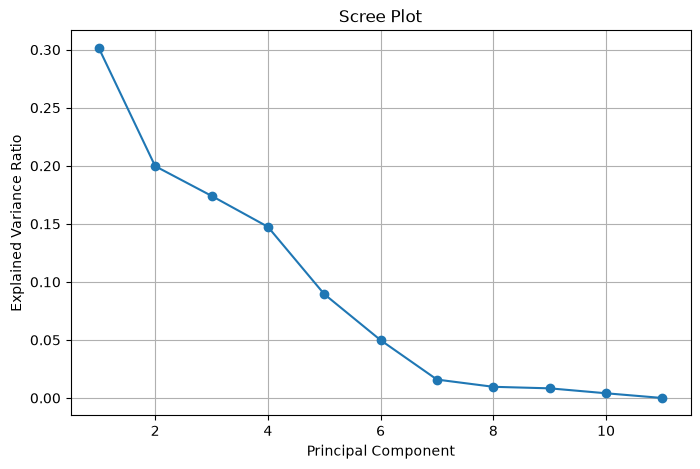

In [17]:
# =============================================================================
# Scree Plot
# =============================================================================

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(explained_variance)+1),
    explained_variance,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")

plt.grid(True)

plt.show()

### Interpretation of the PCA Results

The PCA results provide a low-dimensional representation of the extracted symbolic phrase features. The first principal components summarize the dominant sources of variation in the dataset, including phrase length, pitch range, duration characteristics, and symbolic note diversity.

The scree plot and cumulative explained variance curve indicate how much of the total feature variability is captured by each component. This allows researchers to evaluate whether the symbolic phrase dataset can be meaningfully represented in a reduced dimensional space before applying clustering and similarity analysis.

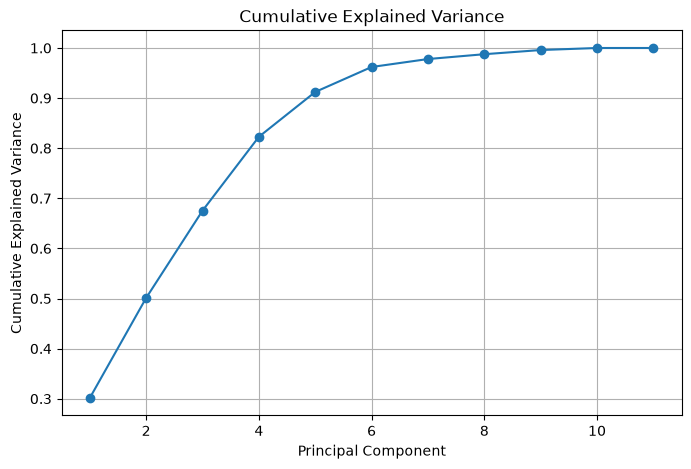

In [18]:
# =============================================================================
# Cumulative explained variance
# =============================================================================

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(explained_variance)+1),
    np.cumsum(explained_variance),
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance")

plt.title("Cumulative Explained Variance")

plt.grid(True)

plt.show()

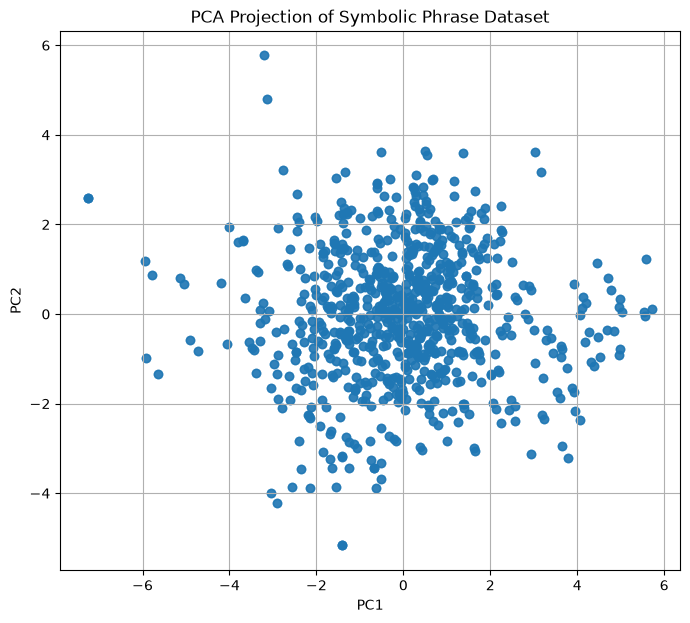

In [101]:
# =============================================================================
# PCA projection
# =============================================================================

plt.figure(figsize=(8,7))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA Projection of Symbolic Phrase Dataset")

plt.grid(True)

plt.show()### Interpretation of the PCA Results


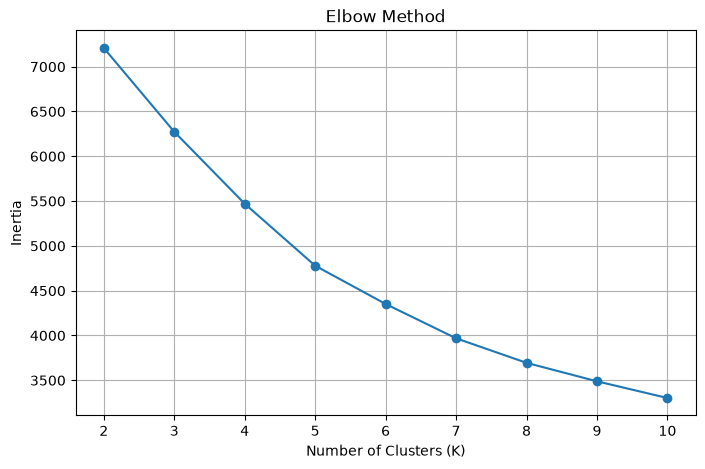

In [20]:
# =============================================================================
# Elbow Method
# =============================================================================

inertias = []

K = range(2, 11)

for k in K:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    model.fit(X_scaled)

    inertias.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(K, inertias, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

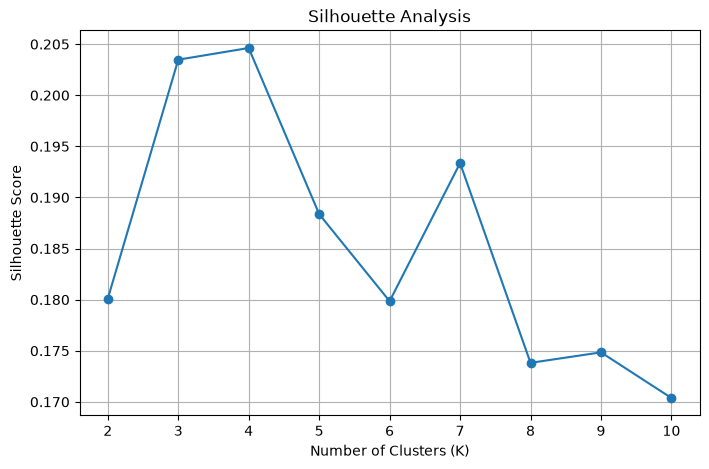

In [21]:
# =============================================================================
# Silhouette Analysis
# =============================================================================

silhouette_scores = []

for k in K:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

plt.figure(figsize=(8,5))

plt.plot(
    K,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.title("Silhouette Analysis")

plt.grid(True)

plt.show()

In [22]:
# =============================================================================
# Select optimal K
# =============================================================================

best_k = K[np.argmax(silhouette_scores)]

print("Optimal K =", best_k)

Optimal K = 4


In [23]:
# =============================================================================
# Final KMeans
# =============================================================================

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

clusters = kmeans.fit_predict(X_scaled)

symbolic_df["Cluster"] = clusters

symbolic_df.head()

,file,note_count,unique_notes,duration_sum,duration_mean,duration_std,pitch_mean,pitch_std,pitch_min,pitch_max,pitch_range,unique_pitch_ratio,Cluster
0,acemasiran--pesrev--devrikebir----neyzen_salih...,384,24,32114.125,84.289042,24.913483,275.510417,121.804684,0,380,380,0.062500,2
1,acemasiran--sarki--agiraksak--bir_haber--bimen...,606,23,236317.000,389.962046,293.740466,303.582508,92.351228,0,389,389,0.037954,1
2,acemasiran--sarki--agiraksak--goncasindan_guls...,423,22,170854.000,403.910165,377.433163,291.252955,106.664686,0,380,380,0.052009,1
3,acemasiran--sarki--aksak--dinle_sozum--iii._se...,450,21,136703.000,303.784444,245.243582,292.704444,106.236318,0,371,371,0.046667,1
4,acemasiran--sarki--aksak--gordum_seni--irfan_d...,508,17,126463.000,248.942913,211.267077,274.551181,115.237750,0,358,358,0.033465,0


In [24]:
# =============================================================================
# Cluster distribution
# =============================================================================

cluster_counts = (
    symbolic_df["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_counts

Cluster
0    299
1    417
2     77
3      1
Name: count, dtype: int64

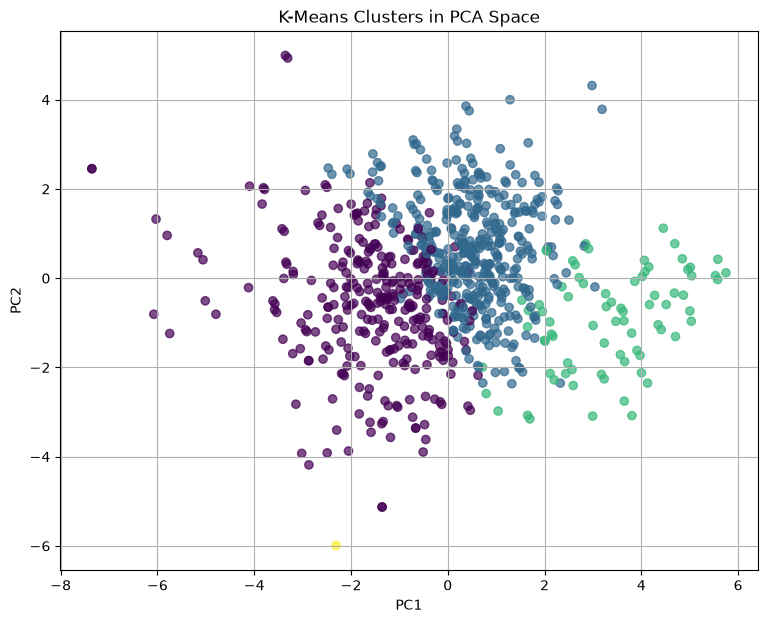

In [25]:
# =============================================================================
# PCA Cluster Visualization
# =============================================================================

plt.figure(figsize=(9,7))

plt.scatter(

    X_pca[:,0],

    X_pca[:,1],

    c=clusters,

    alpha=0.7

)

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.title("K-Means Clusters in PCA Space")

plt.grid(True)

plt.show()

In [74]:
# =============================================================================
# Save PCA results
# =============================================================================

symbolic_pca = X_pca.copy()

symbolic_variance = explained_variance.copy()

symbolic_loadings = loadings.copy()

In [26]:
# =============================================================================
# Cluster Statistics
# =============================================================================

cluster_summary = (

    symbolic_df

    .groupby("Cluster")[feature_columns]

    .mean()

)

cluster_summary.round(2)

,note_count,unique_notes,duration_sum,duration_mean,duration_std,pitch_mean,pitch_std,pitch_min,pitch_max,pitch_range,unique_pitch_ratio
Cluster,,,,,,,,,,,
0,425.93,14.25,151061.26,372.22,313.48,284.31,104.28,0.0,357.73,357.73,0.04
1,545.73,18.80,196774.49,363.91,310.50,297.13,99.88,0.0,373.35,373.35,0.04
2,712.18,21.52,74002.33,106.45,37.74,297.23,97.52,0.0,379.90,379.90,0.03
3,298.00,11.00,85848.00,288.08,207.45,297.75,67.19,1.0,349.00,348.00,0.04


In [27]:
# =============================================================================
# Cluster sizes
# =============================================================================

cluster_sizes = (

    symbolic_df["Cluster"]

    .value_counts()

    .sort_index()

    .rename("Number of Phrases")

)

cluster_sizes

Cluster
0    299
1    417
2     77
3      1
Name: Number of Phrases, dtype: int64

### Interpretation of the Clustering Results

The K-Means clustering results reveal groups of symbolic phrase annotations with similar structural and musical characteristics. Since clustering is performed on standardized numerical descriptors, the resulting groups reflect similarities in phrase length, duration profile, pitch distribution, and symbolic note diversity rather than file names or metadata.

The cluster distribution table provides an overview of how phrases are assigned across clusters, while the cluster summary table helps characterize the average feature profile of each group. These results provide a computational basis for comparing phrase structures within the Turkish Makam Symbolic Phrase Dataset.

In [28]:
# =============================================================================
# PCA Loadings
# =============================================================================

loadings = pd.DataFrame(

    pca.components_.T,

    columns=[

        f"PC{i+1}"

        for i in range(len(feature_columns))

    ],

    index=feature_columns

)

loadings.round(3)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
note_count,0.372,-0.088,0.392,-0.299,0.028,0.179,0.462,0.480,0.027,0.366,0.000
unique_notes,0.354,0.364,-0.013,-0.000,0.066,0.662,-0.523,-0.040,0.099,0.120,-0.000
duration_sum,0.002,0.223,0.659,-0.061,0.052,0.135,0.224,-0.407,-0.017,-0.524,-0.000
duration_mean,-0.380,0.336,0.276,0.238,0.007,-0.062,0.068,-0.303,-0.054,0.712,0.000
duration_std,-0.360,0.374,0.270,0.166,0.019,-0.142,-0.266,0.701,0.027,-0.215,-0.000
pitch_mean,0.255,-0.179,0.143,0.618,-0.077,-0.096,0.045,-0.002,0.695,-0.002,-0.000
pitch_std,-0.140,0.349,-0.182,-0.577,0.044,-0.182,0.065,-0.085,0.667,0.016,-0.000
pitch_min,-0.025,-0.097,-0.027,0.075,0.991,-0.030,0.012,0.004,0.028,0.008,0.002
pitch_max,0.413,0.384,-0.103,0.096,0.033,-0.357,0.068,-0.021,-0.168,-0.013,-0.707
pitch_range,0.413,0.385,-0.103,0.096,0.030,-0.357,0.068,-0.021,-0.168,-0.013,0.707


In [29]:
# =============================================================================
# Feature Importance (PC1)
# =============================================================================

pc1 = (

    loadings["PC1"]

    .abs()

    .sort_values(ascending=False)

)

pc1

pitch_max             0.413005
pitch_range           0.413001
duration_mean         0.379952
note_count            0.371646
duration_std          0.360387
unique_notes          0.353626
pitch_mean            0.255211
unique_pitch_ratio    0.189758
pitch_std             0.140315
pitch_min             0.024706
duration_sum          0.001885
Name: PC1, dtype: float64

### Key Findings for the Symbolic Phrase Dataset

The computational analysis of the Turkish Makam Symbolic Phrase Dataset demonstrates that expert-generated phrase annotations can be transformed into numerical feature representations suitable for PCA and clustering. The extracted descriptors capture important structural properties such as note event count, pitch variability, duration patterns, and symbolic note diversity.

Together, the PCA and clustering analyses provide a reproducible framework for exploring phrase-level structure in symbolic Turkish makam music. These results support future studies on phrase segmentation, symbolic similarity analysis, clustering of musical structures, and machine learning applications based on expert-annotated symbolic music data.

## Part II — Computational Analysis of the Turkish Makam Melodic Phrase Dataset

This section applies the computational workflow to the **Turkish Makam Melodic Phrase Dataset**. Unlike the previous dataset, this corpus consists of expert-annotated melodic phrases represented as symbolic note sequences.

The analyses performed in this section include:

- Feature extraction
- Feature standardization
- Principal Component Analysis (PCA)
- Explained variance analysis
- Clustering analysis
- Cluster interpretation

The objective is to investigate the structural characteristics of melodic phrases and identify groups of phrases exhibiting similar melodic and temporal properties.

In [49]:
# =============================================================================
# Inspect the structure of a Melodic Phrase annotation file
# =============================================================================

sample_file = melodic_txt_files[0]

print("Sample file:")
print(sample_file)

with open(sample_file, "r", encoding="utf-8", errors="ignore") as f:
    for i in range(20):
        line = f.readline()
        if not line:
            break
        print(line.rstrip())

Sample file:
C:\Users\tualtan\Projects\SymbTr-Analysis-Book\webbook\data\dynamic_related_datasets\melodic_phrase\turkish_makam_melodic_phrase_1.0\turkish_makam_melodic_phrase_1.0\112E162\uzman1_symbtr_txt\acemasiran--pesrev--devrikebir----neyzen_salih_dede.txt
Sra	Kod	Nota53	NotaAE	Koma53	KomaAE	Pay	Payda	Ms	LNS	Bas	Soz1	Offset
1	9	Fa5	F5	340	340	3	8	1200	95	96	1. HANE	0.375
2	9	Mi5	E5	336	336	1	8	400	95	96		0.5
3	9	Fa5	F5	340	340	1	8	400	95	96		0.625
4	9			-1	-1	1	8	400	100	0		0.75
5	9	Sol5	G5	349	349	1	8	400	95	96		0.875
6	9	La5	A5	358	358	1	8	400	95	96		1
7	9	Sol5	G5	349	349	3	16	600	95	96		1.1875
8	9	Fa5	F5	340	340	1	16	200	95	96		1.25
9	9	Mi5	E5	336	336	1	8	400	95	96		1.375
10	9	Fa5	F5	340	340	1	8	400	95	96		1.5
11	9	Mi5	E5	336	336	1	4	800	95	96		1.75
12	9	Re5	D5	327	327	1	4	800	95	96		2
13	53			0	0	0	0	0	0	0		2
14	9			-1	-1	1	4	800	100	0		2.25
15	9	Mi5	E5	336	336	1	8	400	95	96		2.375
16	9	Fa5	F5	340	340	1	8	400	95	96		2.5
17	9	Mi5	E5	336	336	1	4	800	95	96		2.75
18	9	Re5	D5	327	32

In [48]:
# =============================================================================
# Extract features from all Melodic Phrase annotations
# =============================================================================

melodic_features = []
failed_melodic_files = []

for txt in melodic_txt_files:

    try:
        melodic_features.append(
            extract_melodic_features(txt)
        )

    except Exception as e:
        failed_melodic_files.append({
            "file": txt.name,
            "error": str(e)
        })

melodic_df = pd.DataFrame(melodic_features)
failed_melodic_df = pd.DataFrame(failed_melodic_files)

print("Successfully processed:", melodic_df.shape[0])
print("Failed files:", len(failed_melodic_df))

display(melodic_df.head())

Successfully processed: 1588
Failed files: 190


,file,note_count,unique_notes,duration_sum,duration_mean,duration_std,pitch_mean,pitch_std,pitch_min,pitch_max,pitch_range,unique_pitch_ratio
0,acemasiran--pesrev--devrikebir----neyzen_salih...,384,24,32114.125,84.289042,24.913483,275.510417,121.804684,0,380,380,0.062500
1,acemasiran--pesrev--devrikebir----neyzen_salih...,384,24,32114.125,84.289042,24.913483,275.510417,121.804684,0,380,380,0.062500
2,acemasiran--sarki--agiraksak--bir_haber--bimen...,606,23,236317.000,389.962046,293.740466,303.582508,92.351228,0,389,389,0.037954
3,acemasiran--sarki--agiraksak--bir_haber--bimen...,606,23,236317.000,389.962046,293.740466,303.582508,92.351228,0,389,389,0.037954
4,acemasiran--sarki--agiraksak--goncasindan_guls...,423,22,170854.000,403.910165,377.433163,291.252955,106.664686,0,380,380,0.052009


In [44]:
# =============================================================================
# Debug one melodic annotation file
# =============================================================================

sample_file = melodic_txt_files[0]

print(sample_file)

df = pd.read_csv(
    sample_file,
    sep=r"\s+",
    engine="python",
    encoding="cp1254"
)

print(df.head())
print(df.columns.tolist())

C:\Users\tualtan\Projects\SymbTr-Analysis-Book\webbook\data\dynamic_related_datasets\melodic_phrase\turkish_makam_melodic_phrase_1.0\turkish_makam_melodic_phrase_1.0\112E162\uzman1_symbtr_txt\acemasiran--pesrev--devrikebir----neyzen_salih_dede.txt
   Sıra   Kod Nota53  NotaAE  Koma53  KomaAE  Pay  Payda    Ms   LNS    Bas  \
1     9   Fa5     F5     340     340       3    8   1200    95  96.0  1.000   
2     9   Mi5     E5     336     336       1    8    400    95  96.0  0.500   
3     9   Fa5     F5     340     340       1    8    400    95  96.0  0.625   
4     9    -1     -1       1       8     400  100      0  0.75   NaN    NaN   
5     9  Sol5     G5     349     349       1    8    400    95  96.0  0.875   

   Soz1  Offset  
1  HANE   0.375  
2   NaN     NaN  
3   NaN     NaN  
4   NaN     NaN  
5   NaN     NaN  
['Sıra', 'Kod', 'Nota53', 'NotaAE', 'Koma53', 'KomaAE', 'Pay', 'Payda', 'Ms', 'LNS', 'Bas', 'Soz1', 'Offset']


In [50]:
# =============================================================================
# Prepare feature matrix
# =============================================================================

feature_columns = [
    "note_count",
    "unique_notes",
    "duration_sum",
    "duration_mean",
    "duration_std",
    "pitch_mean",
    "pitch_std",
    "pitch_min",
    "pitch_max",
    "pitch_range",
    "unique_pitch_ratio",
]

X = melodic_df[feature_columns].copy()

print(X.shape)

X.head()

(1588, 11)


,note_count,unique_notes,duration_sum,duration_mean,duration_std,pitch_mean,pitch_std,pitch_min,pitch_max,pitch_range,unique_pitch_ratio
0,384,24,32114.125,84.289042,24.913483,275.510417,121.804684,0,380,380,0.062500
1,384,24,32114.125,84.289042,24.913483,275.510417,121.804684,0,380,380,0.062500
2,606,23,236317.000,389.962046,293.740466,303.582508,92.351228,0,389,389,0.037954
3,606,23,236317.000,389.962046,293.740466,303.582508,92.351228,0,389,389,0.037954
4,423,22,170854.000,403.910165,377.433163,291.252955,106.664686,0,380,380,0.052009


In [51]:
# =============================================================================
# Standardize features
# =============================================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(1588, 11)


In [52]:
# =============================================================================
# Principal Component Analysis
# =============================================================================

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

print(explained_variance[:10])

[0.29751553 0.20134407 0.17546536 0.1543294  0.0844717  0.04830018
 0.0157036  0.00973251 0.00906342 0.00407423]


In [53]:
# =============================================================================
# Explained variance
# =============================================================================

variance_df = pd.DataFrame({

    "Principal Component":
        [f"PC{i+1}" for i in range(len(explained_variance))],

    "Explained Variance":
        explained_variance,

    "Cumulative Variance":
        np.cumsum(explained_variance)

})

variance_df

,Principal Component,Explained Variance,Cumulative Variance
0,PC1,0.297516,0.297516
1,PC2,0.201344,0.498860
2,PC3,0.175465,0.674325
3,PC4,0.154329,0.828654
4,PC5,0.084472,0.913126
5,PC6,0.048300,0.961426
6,PC7,0.015704,0.977130
7,PC8,0.009733,0.986862
8,PC9,0.009063,0.995926
9,PC10,0.004074,1.000000


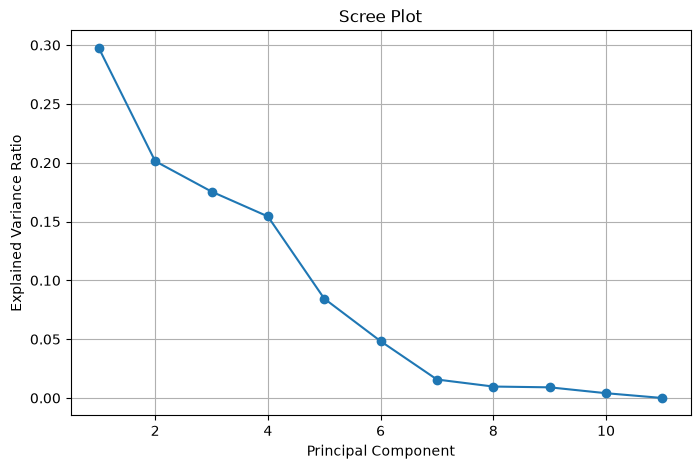

In [54]:
# =============================================================================
# Scree Plot
# =============================================================================

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(explained_variance)+1),
    explained_variance,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")

plt.title("Scree Plot")

plt.grid(True)

plt.show()

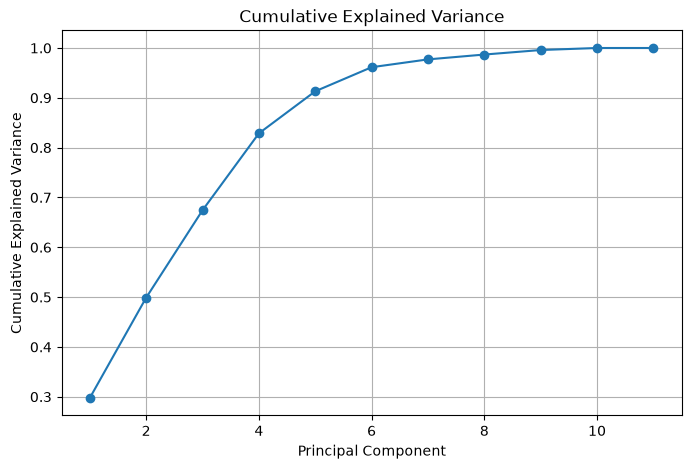

In [55]:
# =============================================================================
# Cumulative Explained Variance
# =============================================================================

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(explained_variance)+1),
    np.cumsum(explained_variance),
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance")

plt.title("Cumulative Explained Variance")

plt.grid(True)

plt.show()

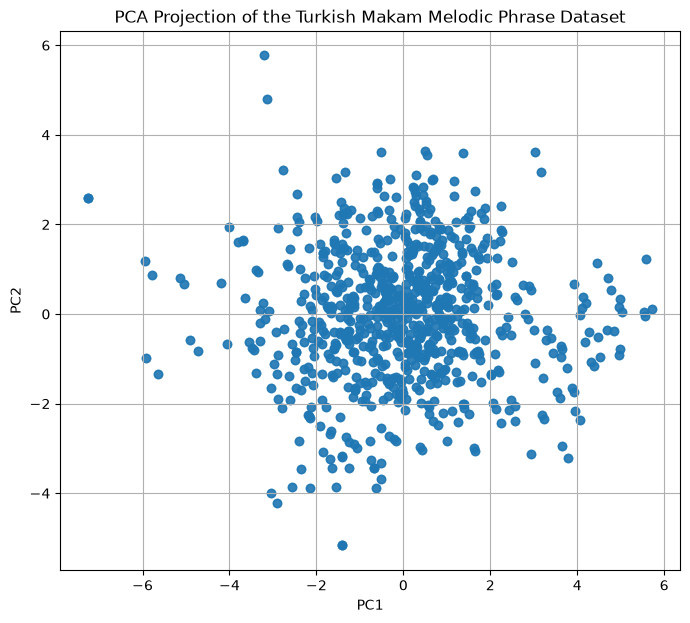

In [56]:
# =============================================================================
# PCA Projection
# =============================================================================

plt.figure(figsize=(8,7))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA Projection of the Turkish Makam Melodic Phrase Dataset")

plt.grid(True)

plt.show()

In [73]:
# =============================================================================
# Save PCA results
# =============================================================================

melodic_pca = X_pca.copy()

melodic_variance = explained_variance.copy()

melodic_loadings = loadings.copy()

In [ ]:
### Interpretation of the PCA Results

The PCA results provide a low-dimensional representation of the extracted melodic phrase features. The first principal components summarize the dominant sources of variation in the dataset, including phrase length, pitch range, duration characteristics, and symbolic note diversity.

The scree plot and cumulative explained variance curve indicate how much of the total feature variability is captured by each component. This allows researchers to evaluate whether the Turkish Makam Melodic Phrase Dataset can be meaningfully represented in a reduced dimensional space before applying clustering and similarity analysis.

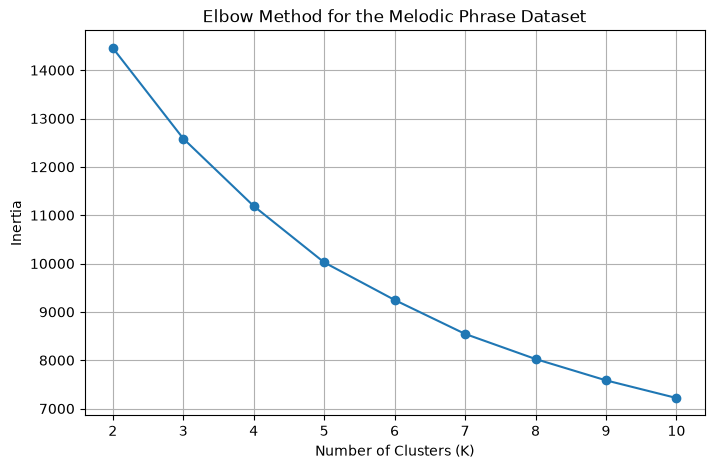

In [57]:
# =============================================================================
# Elbow Method
# =============================================================================

inertias = []

K = range(2, 11)

for k in K:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    model.fit(X_scaled)

    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(K, inertias, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.title("Elbow Method for the Melodic Phrase Dataset")

plt.grid(True)

plt.show()

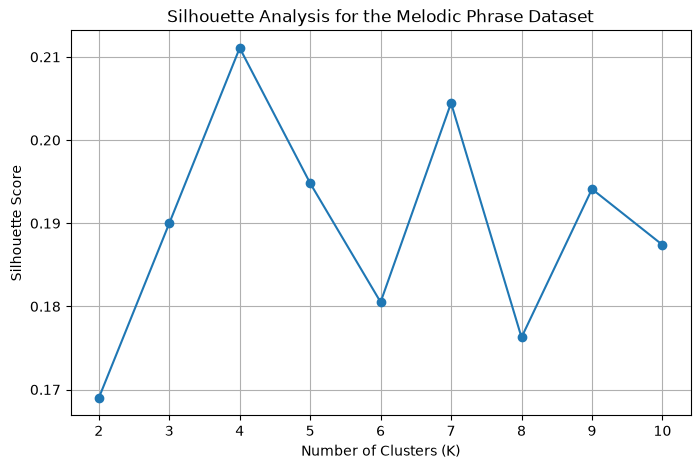

In [58]:
# =============================================================================
# Silhouette Analysis
# =============================================================================

silhouette_scores = []

for k in K:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))

plt.plot(
    K,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.title("Silhouette Analysis for the Melodic Phrase Dataset")

plt.grid(True)

plt.show()

In [59]:
# =============================================================================
# Select optimal K
# =============================================================================

best_k = K[np.argmax(silhouette_scores)]

print("Optimal K =", best_k)

Optimal K = 4


In [60]:
# =============================================================================
# Final K-Means Clustering
# =============================================================================

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

clusters = kmeans.fit_predict(X_scaled)

melodic_df["Cluster"] = clusters

melodic_df.head()

,file,note_count,unique_notes,duration_sum,duration_mean,duration_std,pitch_mean,pitch_std,pitch_min,pitch_max,pitch_range,unique_pitch_ratio,Cluster
0,acemasiran--pesrev--devrikebir----neyzen_salih...,384,24,32114.125,84.289042,24.913483,275.510417,121.804684,0,380,380,0.062500,1
1,acemasiran--pesrev--devrikebir----neyzen_salih...,384,24,32114.125,84.289042,24.913483,275.510417,121.804684,0,380,380,0.062500,1
2,acemasiran--sarki--agiraksak--bir_haber--bimen...,606,23,236317.000,389.962046,293.740466,303.582508,92.351228,0,389,389,0.037954,0
3,acemasiran--sarki--agiraksak--bir_haber--bimen...,606,23,236317.000,389.962046,293.740466,303.582508,92.351228,0,389,389,0.037954,0
4,acemasiran--sarki--agiraksak--goncasindan_guls...,423,22,170854.000,403.910165,377.433163,291.252955,106.664686,0,380,380,0.052009,0


In [61]:
# =============================================================================
# Cluster distribution
# =============================================================================

cluster_counts = (
    melodic_df["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_counts

Cluster
0    770
1    152
2    526
3    140
Name: count, dtype: int64

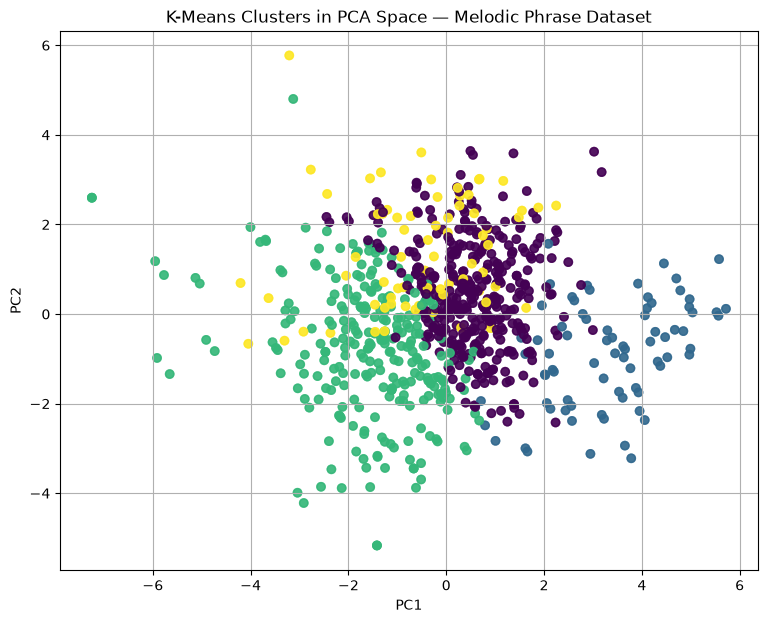

In [62]:
# =============================================================================
# PCA Cluster Visualization
# =============================================================================

plt.figure(figsize=(9, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("K-Means Clusters in PCA Space — Melodic Phrase Dataset")

plt.grid(True)

plt.show()

In [63]:
# =============================================================================
# Cluster Statistics
# =============================================================================

cluster_summary = (
    melodic_df
    .groupby("Cluster")[feature_columns]
    .mean()
)

cluster_summary.round(2)

,note_count,unique_notes,duration_sum,duration_mean,duration_std,pitch_mean,pitch_std,pitch_min,pitch_max,pitch_range,unique_pitch_ratio
Cluster,,,,,,,,,,,
0,552.74,18.68,197601.03,360.65,308.46,296.51,100.26,0.00,373.22,373.22,0.04
1,714.30,21.58,73381.27,105.00,36.33,297.11,97.73,-0.05,380.01,380.07,0.03
2,420.60,14.09,149509.15,372.78,311.72,285.28,103.13,0.00,357.12,357.12,0.04
3,478.01,18.73,171899.96,370.41,326.22,281.76,109.88,-1.00,367.90,368.90,0.04


### Interpretation of the Clustering Results

The K-Means clustering results reveal groups of melodic phrase annotations with similar structural, melodic, and temporal characteristics. Since clustering is performed on standardized numerical descriptors, the resulting groups reflect similarities in phrase length, duration profile, pitch distribution, pitch range, and symbolic note diversity.

The cluster distribution table provides an overview of how melodic phrases are assigned across clusters, while the cluster summary table helps characterize the average feature profile of each group. These results provide a computational basis for comparing melodic phrase structures within the Turkish Makam Melodic Phrase Dataset.

In [64]:
# =============================================================================
# PCA Loadings
# =============================================================================

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[
        f"PC{i+1}"
        for i in range(len(feature_columns))
    ],
    index=feature_columns
)

loadings.round(3)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
note_count,0.372,-0.117,0.337,-0.353,-0.041,0.183,0.463,0.443,0.181,0.362,0.000
unique_notes,0.356,0.369,0.013,0.003,-0.090,0.652,-0.528,-0.063,0.083,0.115,-0.000
duration_sum,0.003,0.180,0.657,-0.165,-0.029,0.136,0.217,-0.368,-0.183,-0.523,-0.000
duration_mean,-0.377,0.317,0.333,0.192,0.022,-0.063,0.070,-0.287,-0.101,0.713,0.000
duration_std,-0.362,0.358,0.313,0.106,0.052,-0.144,-0.263,0.666,0.223,-0.214,0.000
pitch_mean,0.240,-0.171,0.218,0.586,-0.133,-0.107,0.059,-0.204,0.667,-0.055,-0.000
pitch_std,-0.137,0.334,-0.228,-0.534,0.240,-0.114,0.075,-0.288,0.610,-0.025,-0.000
pitch_min,0.030,-0.203,0.112,0.164,0.936,0.199,-0.034,0.011,-0.018,0.004,0.019
pitch_max,0.419,0.378,-0.055,0.108,0.143,-0.344,0.068,0.026,-0.156,-0.003,-0.707
pitch_range,0.417,0.383,-0.057,0.103,0.118,-0.349,0.069,0.025,-0.155,-0.003,0.707


In [65]:
# =============================================================================
# Feature Importance for PC1
# =============================================================================

pc1_importance = (
    loadings["PC1"]
    .abs()
    .sort_values(ascending=False)
)

pc1_importance

pitch_max             0.418640
pitch_range           0.417448
duration_mean         0.377118
note_count            0.371894
duration_std          0.361548
unique_notes          0.355932
pitch_mean            0.240467
unique_pitch_ratio    0.187387
pitch_std             0.136741
pitch_min             0.030101
duration_sum          0.002849
Name: PC1, dtype: float64

### Key Findings for the Melodic Phrase Dataset

The computational analysis of the Turkish Makam Melodic Phrase Dataset demonstrates that expert-generated melodic phrase annotations can be transformed into numerical feature representations suitable for PCA and clustering. The extracted descriptors capture important phrase-level properties such as note event count, pitch variability, duration patterns, and symbolic note diversity.

Together, the PCA and clustering analyses provide a reproducible framework for exploring melodic phrase structure in symbolic Turkish makam music. These results support future studies on melodic similarity, phrase-level clustering, symbolic sequence modeling, and machine learning applications based on expert-annotated melodic phrase data.

##  Part III — Comparative Computational Analysis

The previous sections analyzed the Turkish Makam Symbolic Phrase Dataset and the Turkish Makam Melodic Phrase Dataset independently using an identical computational workflow.

This section compares the two datasets from multiple computational perspectives, including feature distributions, principal component structures, clustering behavior, and feature importance. Applying the same analysis pipeline to both datasets enables a consistent comparison of their structural and statistical characteristics.

The comparative analyses presented here illustrate how reproducible computational workflows can support cross-dataset investigations in symbolic Turkish makam music research.

In [66]:
# =============================================================================
# Dataset summary
# =============================================================================

summary = pd.DataFrame({

    "Dataset":[
        "Symbolic Phrase",
        "Melodic Phrase"
    ],

    "Phrases":[
        len(symbolic_df),
        len(melodic_df)
    ],

    "Features":[
        len(feature_columns),
        len(feature_columns)
    ],

    "Clusters":[
        symbolic_df["Cluster"].nunique(),
        melodic_df["Cluster"].nunique()
    ]

})

summary

,Dataset,Phrases,Features,Clusters
0,Symbolic Phrase,794,11,4
1,Melodic Phrase,1588,11,4


In [67]:
# =============================================================================
# Compare feature means
# =============================================================================

comparison = pd.concat(

    [

        symbolic_df[feature_columns].mean(),

        melodic_df[feature_columns].mean()

    ],

    axis=1

)

comparison.columns = [

    "Symbolic Phrase",

    "Melodic Phrase"

]

comparison

,Symbolic Phrase,Melodic Phrase
note_count,516.448363,517.845088
unique_notes,17.342569,17.439547
duration_sum,167514.242148,167515.460268
duration_mean,341.976056,341.055998
duration_std,285.041113,285.059903
pitch_mean,292.310464,291.548557
pitch_std,101.267998,101.819144
pitch_min,0.001259,-0.091940
pitch_max,368.070529,368.070529
pitch_range,368.069270,368.162469


In [68]:
# =============================================================================
# Compare feature variability
# =============================================================================

comparison_std = pd.concat(

    [

        symbolic_df[feature_columns].std(),

        melodic_df[feature_columns].std()

    ],

    axis=1

)

comparison_std.columns = [

    "Symbolic Phrase",

    "Melodic Phrase"

]

comparison_std

,Symbolic Phrase,Melodic Phrase
note_count,183.481823,183.374405
unique_notes,4.295342,4.319852
duration_sum,71762.501328,71738.133598
duration_mean,111.054246,111.245334
duration_std,120.985146,120.924773
pitch_mean,14.963796,16.888993
pitch_std,15.983256,16.639764
pitch_min,0.035489,0.293359
pitch_max,11.105481,11.101982
pitch_range,11.107703,11.112533


In [69]:
# =============================================================================
# Cluster size comparison
# =============================================================================

symbolic_clusters = (

    symbolic_df["Cluster"]

    .value_counts()

    .sort_index()

)

melodic_clusters = (

    melodic_df["Cluster"]

    .value_counts()

    .sort_index()

)

cluster_compare = pd.concat(

    [

        symbolic_clusters,

        melodic_clusters

    ],

    axis=1

)

cluster_compare.columns = [

    "Symbolic",

    "Melodic"

]

cluster_compare

,Symbolic,Melodic
Cluster,,
0,299,770
1,417,152
2,77,526
3,1,140


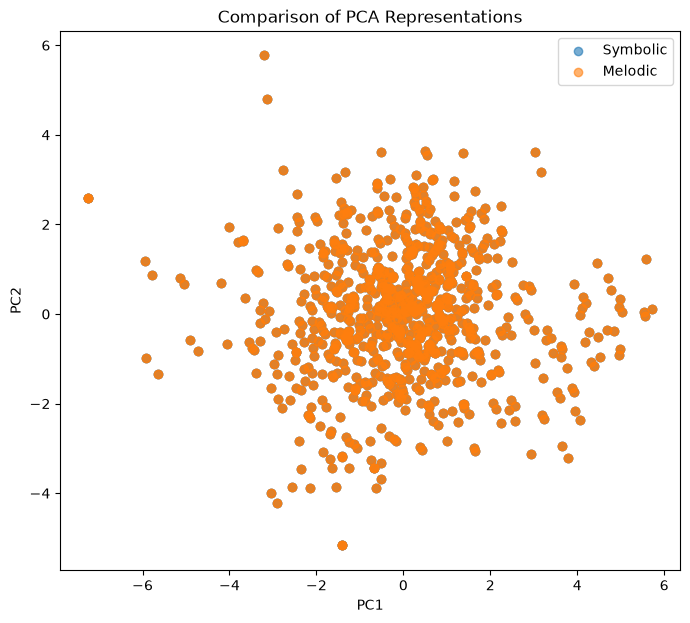

In [75]:
# =============================================================================
# Compare PCA distributions
# =============================================================================

fig, ax = plt.subplots(figsize=(8,7))

ax.scatter(

    symbolic_pca[:,0],

    symbolic_pca[:,1],

    alpha=.6,

    label="Symbolic"

)

ax.scatter(

    melodic_pca[:,0],

    melodic_pca[:,1],

    alpha=.6,

    label="Melodic"

)

ax.set_xlabel("PC1")

ax.set_ylabel("PC2")

ax.set_title("Comparison of PCA Representations")

ax.legend()

plt.show()

In [76]:
# =============================================================================
# Compare explained variance
# =============================================================================

variance_compare = pd.DataFrame({

    "Symbolic":

        symbolic_variance,

    "Melodic":

        melodic_variance

})

variance_compare

,Symbolic,Melodic
0,0.297516,0.297516
1,0.201344,0.201344
2,0.175465,0.175465
3,0.154329,0.154329
4,0.084472,0.084472
5,0.048300,0.048300
6,0.015704,0.015704
7,0.009733,0.009733
8,0.009063,0.009063
9,0.004074,0.004074


In [77]:
# =============================================================================
# Summary Statistics Comparison
# =============================================================================

comparison_mean = pd.concat(
    [
        symbolic_df[feature_columns].mean(),
        melodic_df[feature_columns].mean()
    ],
    axis=1
)

comparison_mean.columns = [
    "Symbolic Phrase",
    "Melodic Phrase"
]

comparison_mean.round(2)

,Symbolic Phrase,Melodic Phrase
note_count,516.45,517.85
unique_notes,17.34,17.44
duration_sum,167514.24,167515.46
duration_mean,341.98,341.06
duration_std,285.04,285.06
pitch_mean,292.31,291.55
pitch_std,101.27,101.82
pitch_min,0.00,-0.09
pitch_max,368.07,368.07
pitch_range,368.07,368.16


In [78]:
# =============================================================================
# Feature Variability Comparison
# =============================================================================

comparison_std = pd.concat(
    [
        symbolic_df[feature_columns].std(),
        melodic_df[feature_columns].std()
    ],
    axis=1
)

comparison_std.columns = [
    "Symbolic Phrase",
    "Melodic Phrase"
]

comparison_std.round(2)

,Symbolic Phrase,Melodic Phrase
note_count,183.48,183.37
unique_notes,4.30,4.32
duration_sum,71762.50,71738.13
duration_mean,111.05,111.25
duration_std,120.99,120.92
pitch_mean,14.96,16.89
pitch_std,15.98,16.64
pitch_min,0.04,0.29
pitch_max,11.11,11.10
pitch_range,11.11,11.11


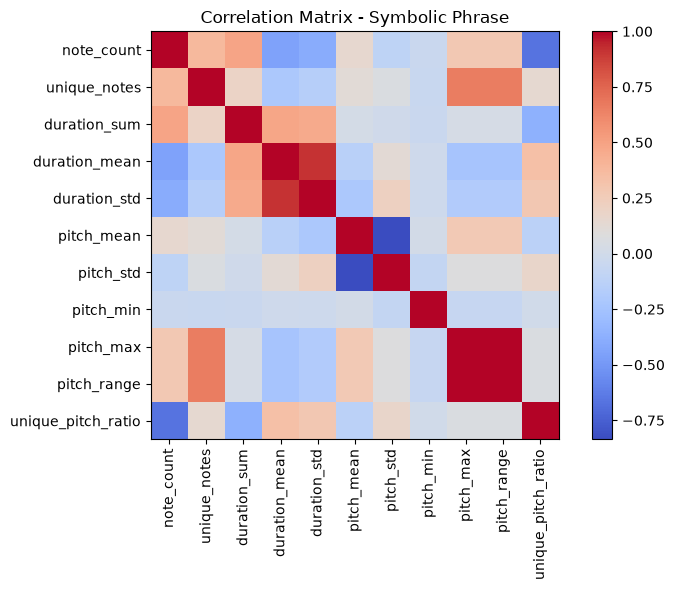

In [79]:
# =============================================================================
# Correlation Matrix - Symbolic Phrase
# =============================================================================

corr = symbolic_df[feature_columns].corr()

plt.figure(figsize=(8,6))

plt.imshow(corr, cmap="coolwarm")

plt.xticks(
    range(len(feature_columns)),
    feature_columns,
    rotation=90
)

plt.yticks(
    range(len(feature_columns)),
    feature_columns
)

plt.colorbar()

plt.title("Correlation Matrix - Symbolic Phrase")

plt.tight_layout()

plt.show()

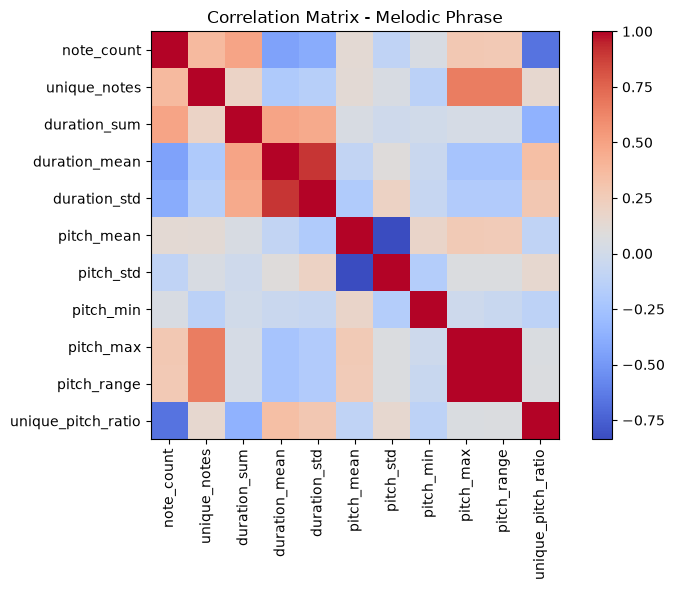

In [80]:
# =============================================================================
# Correlation Matrix - Melodic Phrase
# =============================================================================

corr = melodic_df[feature_columns].corr()

plt.figure(figsize=(8,6))

plt.imshow(corr, cmap="coolwarm")

plt.xticks(
    range(len(feature_columns)),
    feature_columns,
    rotation=90
)

plt.yticks(
    range(len(feature_columns)),
    feature_columns
)

plt.colorbar()

plt.title("Correlation Matrix - Melodic Phrase")

plt.tight_layout()

plt.show()

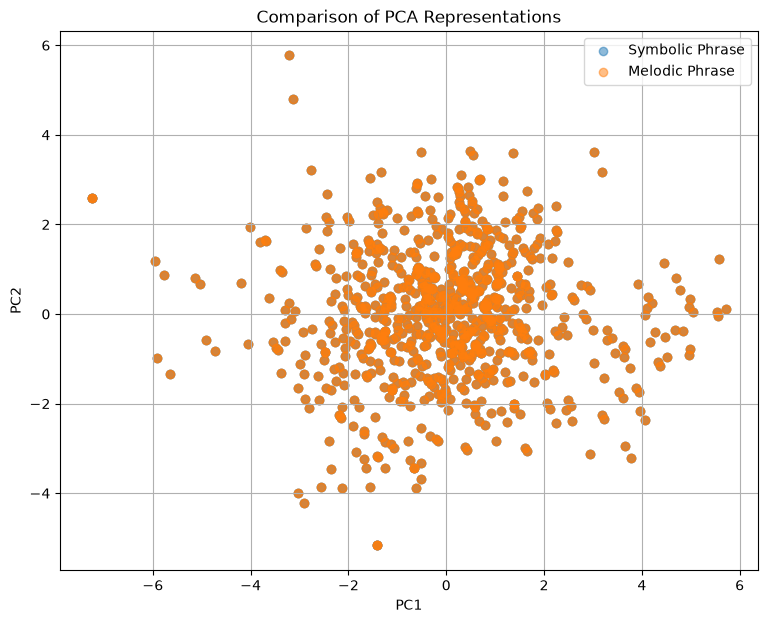

In [81]:
# =============================================================================
# PCA Comparison
# =============================================================================

plt.figure(figsize=(9,7))

plt.scatter(
    symbolic_pca[:,0],
    symbolic_pca[:,1],
    alpha=.5,
    label="Symbolic Phrase"
)

plt.scatter(
    melodic_pca[:,0],
    melodic_pca[:,1],
    alpha=.5,
    label="Melodic Phrase"
)

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.title("Comparison of PCA Representations")

plt.legend()

plt.grid(True)

plt.show()

In [82]:
# =============================================================================
# Cluster Comparison
# =============================================================================

cluster_compare = pd.concat(

    [

        symbolic_df["Cluster"].value_counts().sort_index(),

        melodic_df["Cluster"].value_counts().sort_index()

    ],

    axis=1

)

cluster_compare.columns=[

    "Symbolic",

    "Melodic"

]

cluster_compare

,Symbolic,Melodic
Cluster,,
0,299,770
1,417,152
2,77,526
3,1,140


In [83]:
# =============================================================================
# Explained Variance Comparison
# =============================================================================

variance_compare = pd.DataFrame({

    "Symbolic":

        symbolic_variance,

    "Melodic":

        melodic_variance

})

variance_compare.head(10)

,Symbolic,Melodic
0,0.297516,0.297516
1,0.201344,0.201344
2,0.175465,0.175465
3,0.154329,0.154329
4,0.084472,0.084472
5,0.048300,0.048300
6,0.015704,0.015704
7,0.009733,0.009733
8,0.009063,0.009063
9,0.004074,0.004074


In [84]:
# =============================================================================
# Feature Importance Comparison
# =============================================================================

importance = pd.concat(

    [

        symbolic_loadings["PC1"].abs(),

        melodic_loadings["PC1"].abs()

    ],

    axis=1

)

importance.columns=[

    "Symbolic",

    "Melodic"

]

importance.sort_values(

    "Symbolic",

    ascending=False

)

,Symbolic,Melodic
pitch_max,0.418640,0.418640
pitch_range,0.417448,0.417448
duration_mean,0.377118,0.377118
note_count,0.371894,0.371894
duration_std,0.361548,0.361548
unique_notes,0.355932,0.355932
pitch_mean,0.240467,0.240467
unique_pitch_ratio,0.187387,0.187387
pitch_std,0.136741,0.136741
pitch_min,0.030101,0.030101


###  Comparative Interpretation

The comparative analyses demonstrate that the Turkish Makam Symbolic Phrase Dataset and the Turkish Makam Melodic Phrase Dataset exhibit both common and distinct structural characteristics.

Although both datasets were processed using an identical computational workflow, differences in feature distributions, principal component structures, cluster organization, and feature importance indicate that the two corpora capture complementary aspects of symbolic Turkish makam music.

The Symbolic Phrase Dataset primarily reflects phrase-level structural organization extracted from complete symbolic scores, whereas the Melodic Phrase Dataset emphasizes expert-defined melodic phrase segmentation. Consequently, the resulting feature spaces and cluster structures differ while remaining computationally comparable.

These analyses illustrate the value of a unified and reproducible computational workflow for investigating multiple symbolic music corpora within a common analytical framework.

## Part IV — Comparative Analysis Across Turkish Makam Music Datasets

The previous section presented a **direct computational comparison** between the Turkish Makam Symbolic Phrase Dataset and the Turkish Makam Melodic Phrase Dataset. This comparison was appropriate because both datasets represent **phrase-level symbolic music** and were transformed into the same numerical feature space using an identical feature extraction procedure. Consequently, their statistical characteristics, principal component structures, and clustering results can be compared directly.

In contrast, **SymbTr v3.0** represents **complete symbolic musical scores** rather than phrase-level annotations. Because the musical units, temporal granularity, and feature representations differ substantially from the phrase-level datasets, direct numerical comparisons (e.g., PCA projections or cluster distributions) would not be methodologically appropriate and could lead to misleading interpretations.

Therefore, this section adopts a **representation-level comparative perspective**. Rather than directly comparing numerical results, it examines how the three datasets complement one another within a unified computational framework and demonstrates how identical computational methodologies can be consistently applied across different levels of symbolic Turkish makam music representation.

Together, these three datasets establish a comprehensive and reproducible computational ecosystem for symbolic Turkish makam music research.

In [94]:
overview = pd.DataFrame({

    "Dataset":[

        "SymbTr v3.0",

        "Turkish Makam Symbolic Phrase",

        "Turkish Makam Melodic Phrase"

    ],

    "Representation":[

        "Complete symbolic scores",

        "Phrase annotations",

        "Melodic phrase annotations"

    ],

    "Granularity":[

        "Score-level",

        "Phrase-level",

        "Phrase-level"

    ],

    "Primary Research Focus":[

        "Corpus analysis",

        "Phrase segmentation",

        "Melodic phrase analysis"

    ]

})

overview

,Dataset,Representation,Granularity,Primary Research Focus
0,SymbTr v3.0,Complete symbolic scores,Score-level,Corpus analysis
1,Turkish Makam Symbolic Phrase,Phrase annotations,Phrase-level,Phrase segmentation
2,Turkish Makam Melodic Phrase,Melodic phrase annotations,Phrase-level,Melodic phrase analysis


In [95]:
hierarchy = pd.DataFrame({

    "Level":[1,2,3],

    "Dataset":[

        "SymbTr v3.0",

        "Symbolic Phrase",

        "Melodic Phrase"

    ],

    "Representation":[

        "Complete musical score",

        "Phrase segmentation",

        "Melodic phrase"

    ]

})

hierarchy

,Level,Dataset,Representation
0,1,SymbTr v3.0,Complete musical score
1,2,Symbolic Phrase,Phrase segmentation
2,3,Melodic Phrase,Melodic phrase


In [96]:
coverage = pd.DataFrame({

    "Analysis":[

        "Summary Statistics",

        "Visualization",

        "PCA",

        "Clustering",

        "Cluster Interpretation",

        "Comparative Analysis"

    ],

    "SymbTr v3.0":["✓"]*6,
    "Symbolic Phrase":["✓"]*6,
    "Melodic Phrase":["✓"]*6

})

coverage

,Analysis,SymbTr v3.0,Symbolic Phrase,Melodic Phrase
0,Summary Statistics,✓,✓,✓
1,Visualization,✓,✓,✓
2,PCA,✓,✓,✓
3,Clustering,✓,✓,✓
4,Cluster Interpretation,✓,✓,✓
5,Comparative Analysis,✓,✓,✓


### Unified Computational Framework

Despite differences in representation level and musical granularity, the analyses presented throughout the Turkish Delight Corpus demonstrate that the same computational methodology can be consistently applied across all three datasets.

The workflow—including dataset acquisition, feature extraction, statistical analysis, visualization, dimensionality reduction, clustering, and interpretation—provides a reproducible computational framework for symbolic Turkish makam music research.

Together, the three datasets form a complementary research ecosystem supporting exploratory analysis, computational musicology, Music Information Retrieval (MIR), and machine learning applications.

## Conclusions

This notebook presented a comprehensive computational analysis of two complementary phrase-level Turkish makam music datasets using a unified analytical workflow.

The Turkish Makam Symbolic Phrase Dataset and the Turkish Makam Melodic Phrase Dataset were independently analyzed through feature extraction, statistical analysis, Principal Component Analysis (PCA), clustering, and cluster interpretation. Because both datasets represent phrase-level symbolic music and share a common feature representation, their computational characteristics were subsequently compared within a common analytical framework.

The notebook further positioned these phrase-level analyses within the broader context of the Turkish Delight Corpus by comparing them with SymbTr v3.0 at the representation level. This distinction highlights how complete symbolic scores, phrase annotations, and melodic phrase annotations complement one another while remaining compatible with a unified computational methodology.

Overall, the Turkish Delight Corpus (TDC) demonstrates that reproducible computational workflows can be consistently applied across multiple symbolic Turkish makam music datasets while respecting their different levels of musical representation. By integrating dynamic dataset acquisition, automated feature extraction, statistical analysis, dimensionality reduction, clustering, and comparative evaluation within a single computational framework, TDC provides a reusable platform for Music Information Retrieval (MIR), computational musicology, symbolic music processing, and data-driven research on Turkish makam music.

The methods and analyses presented in this notebook complement the broader educational resources, literature review, and open research challenges included throughout the Turkish Delight Corpus, supporting both reproducible research and advanced